In [2]:
!pip install opencv-python pydicom scikit-image SimpleITK matplotlib

^C
  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached pydicom-3.0.2-py3-none-any.whl.metadata (9.4 kB)
  Using cached simpleitk-2.5.4-cp311-abi3-win_amd64.whl.metadata (7.3 kB)
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 1.1 MB/s eta 0:00:37
    --------------------------------------- 0.8/40.2 MB 1.2 MB/s eta 0:00:33
   - -------------------------------------- 1.0/40.2 MB 995.8 kB/s eta 0:00:40
   - -------------------------------------- 1.0/40.2 MB 995.8 kB/s eta 0:00:40
   - -------------------------------------- 1.0/40.2 MB 995.8 kB/s eta 0:00:40
   - -------------------------------------- 1.0/40.2 MB 995.8 kB/s eta 0:00:40
   - -------------------------------------- 1.3/40.2 MB 722.8 kB/s eta 0:00:54
   - ---------------

In [5]:

# Gerekli kütüphaneleri içe aktarıyoruz
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from skimage import transform
from skimage import data

# Grafiklerde Türkçe karakter sorunu olmaması için
plt.rcParams['font.family'] = 'DejaVu Sans'

print("1. Kısım tamam: Kütüphaneler yüklendi.")

1. Kısım tamam: Kütüphaneler yüklendi.


2. Kısım başladı: Görsel yükleniyor...


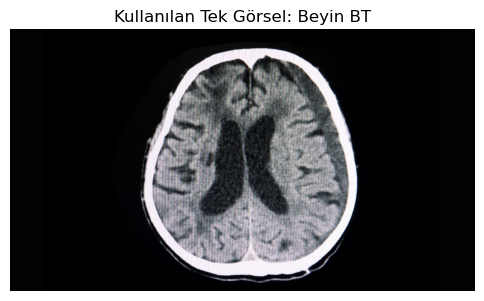

2. Kısım tamam: Beyin BT görüntüsü yüklendi.


In [7]:

# --- 2. GÖRSELİ YÜKLE ---
# Ödevin ilk maddesi: Veri setinden bir görsel
print("2. Kısım başladı: Görsel yükleniyor...")

# Beyin BT resmini dosyadan oku
orijinal_resim = cv.imread('beyin_bt.jpg') 

# Resim bulunamazsa programı durdur
if orijinal_resim is None:
    print("HATA: 'beyin_bt.jpg' bulunamadı! Dosya adını ve konumunu kontrol et.")
else:
    # OpenCV BGR formatında okur, matplotlib RGB istediği için çeviriyoruz
    orijinal_resim = cv.cvtColor(orijinal_resim, cv.COLOR_BGR2RGB)

    # Görseli ekranda gösterelim
    plt.figure(figsize=(6, 6))
    plt.imshow(orijinal_resim, cmap='gray')
    plt.title("Kullanılan Tek Görsel: Beyin BT")
    plt.axis('off')
    plt.show()
    print("2. Kısım tamam: Beyin BT görüntüsü yüklendi.")

3. Kısım başladı: SIFT algoritması çalışıyor...


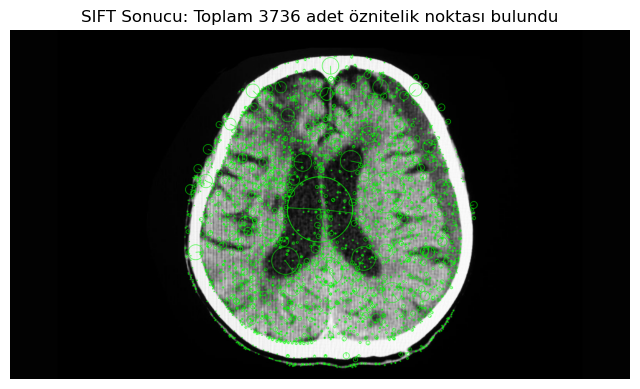

3. Kısım tamam: SIFT algoritması 3736 adet öznitelik buldu.


In [8]:

# --- 3. ÖZNİTELİK ÇIKARMA ALGORİTMASI: SIFT ---
print("3. Kısım başladı: SIFT algoritması çalışıyor...")

# SIFT algoritmasını başlatıyoruz - Bu ödevin 2. maddesi
sift_algoritmasi = cv.SIFT_create()

# SIFT için resmin gri ve uint8 tipinde olması gerekiyor
# skimage bazen float64 veriyor, onu düzeltiyoruz
if orijinal_resim.dtype != np.uint8:
    resim_duzeltilmis = (orijinal_resim * 255).astype(np.uint8)
else:
    resim_duzeltilmis = orijinal_resim

# Eğer resim renkli ise gri tona çeviriyoruz
if len(resim_duzeltilmis.shape) == 3:
    gri_resim = cv.cvtColor(resim_duzeltilmis, cv.COLOR_RGB2GRAY)
else:
    gri_resim = resim_duzeltilmis

# SIFT ile öznitelik noktalarını ve tanımlayıcılarını buluyoruz
noktalar, tanimlayicilar = sift_algoritmasi.detectAndCompute(gri_resim, None)

# Bulunan öznitelik noktalarını resmin üzerine yeşil daireler ile çiziyoruz
sonuc_resmi = cv.drawKeypoints(gri_resim, noktalar, None, color=(0, 255, 0), flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Sonucu ekrana yazdırıyoruz
plt.figure(figsize=(8, 8))
plt.imshow(sonuc_resmi, cmap='gray')
plt.title(f"SIFT Sonucu: Toplam {len(noktalar)} adet öznitelik noktası bulundu")
plt.axis('off')
plt.show()

print(f"3. Kısım tamam: SIFT algoritması {len(noktalar)} adet öznitelik buldu.")

In [11]:

# --- 4. MODEL SONUCU ---


print("4. Kısım başladı: Model sonucu hesaplanıyor...")

# SIFT'ten çıkan tanımlayıcıların sayısı = çıkarılan özellik sayısı
ozellik_sayisi = tanimlayicilar.shape[0]
ozellik_boyutu = tanimlayicilar.shape[1]

print("--------------------------------------")
print("ÖDEV SONUCU")
print("--------------------------------------")
print(f"Kullanılan Algoritma: SIFT")
print(f"Toplam Bulunan Öznitelik Noktası Sayısı: {len(noktalar)}")
print(f"Her bir öznitelik vektörünün boyutu: {ozellik_boyutu}")
print(f"Toplam Çıkarılan Özellik Vektörü: {ozellik_sayisi} x {ozellik_boyutu}")


4. Kısım başladı: Model sonucu hesaplanıyor...
--------------------------------------
ÖDEV SONUCU
--------------------------------------
Kullanılan Algoritma: SIFT
Toplam Bulunan Öznitelik Noktası Sayısı: 3736
Her bir öznitelik vektörünün boyutu: 128
Toplam Çıkarılan Özellik Vektörü: 3736 x 128
